# Question 1 : Impact Relatif des Facteurs sur le Bonheur

**Objectif :** Visualiser l'influence spécifique de l'économie, du soutien social, de la santé, de la liberté, de la générosité et de la corruption sur le score de bonheur (`Life Ladder`).

In [55]:
# Importations essentielles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Style graphique (optionnel)
sns.set_theme(style="whitegrid")

print("Bibliothèques importées.")

Bibliothèques importées.


In [56]:
# --- Chargement et Préparation Rapide ---

# Chemin du fichier
file_path = 'CSVs/world_happiness_report_2024.csv' 
# Si vous avez téléversé le dossier WorldHappinessReport/, le chemin pourrait être :
# file_path = 'WorldHappinessReport/CSVs/world_happiness_report_2024.csv'

# Colonnes nécessaires pour la question 1
colonnes_necessaires = [
    'Life Ladder',
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy at birth',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# Charger, sélectionner les colonnes et supprimer les lignes avec NaN en une seule étape
try:
    df_clean = pd.read_csv(file_path, usecols=colonnes_necessaires).dropna()
    print(f"Données chargées et nettoyées. Nombre d'observations conservées : {len(df_clean)}")
    
    # Afficher un aperçu rapide (optionnel)
    # display(df_clean.head())
    # display(df_clean.describe())

except FileNotFoundError:
    print(f"ERREUR : Le fichier {file_path} n'a pas été trouvé. Vérifiez le chemin.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

Données chargées et nettoyées. Nombre d'observations conservées : 2103


Formule utilisée : Q("Life Ladder") ~ Q("Log GDP per capita") + Q("Social support") + Q("Healthy life expectancy at birth") + Q("Freedom to make life choices") + Q("Generosity") + Q("Perceptions of corruption")
Modèle de régression ajusté.
Génération du graphique des coefficients...


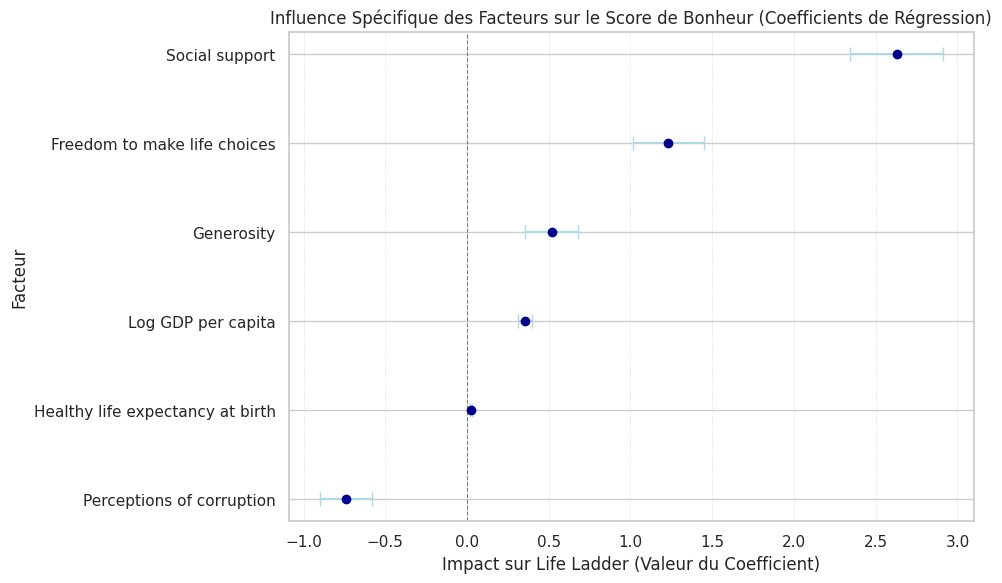

In [57]:
# --- Analyse et Graphique Principal (Coefficient Plot) ---

if 'df_clean' in locals(): # Vérifie si df_clean a été créé avec succès
    # Définir la formule de régression avec Q() pour les noms avec espaces/caractères spéciaux
    predictor_cols_q = [f'Q("{col}")' for col in colonnes_necessaires if col != 'Life Ladder']
    formula = f'Q("Life Ladder") ~ {" + ".join(predictor_cols_q)}'
    
    print(f"Formule utilisée : {formula}")

    try:
        # Ajuster le modèle OLS (Ordinary Least Squares)
        model = smf.ols(formula=formula, data=df_clean)
        results = model.fit()
        print("Modèle de régression ajusté.")

        # --- Création du Graphique des Coefficients ---
        print("Génération du graphique des coefficients...")
        
        # Extraire coefficients et intervalles de confiance (sans l'intercept)
        coeffs = results.params.drop('Intercept')
        conf_int = results.conf_int().drop('Intercept')
        
        # Nettoyer les noms pour les labels de l'axe Y
        coeffs.index = [name.replace('Q("', '').replace('")', '') for name in coeffs.index]
        conf_int.index = [name.replace('Q("', '').replace('")', '') for name in conf_int.index]
        
        # Trier pour une meilleure lisibilité
        coeffs_sorted = coeffs.sort_values()
        conf_int_sorted = conf_int.loc[coeffs_sorted.index]
        
        # Créer le graphique
        plt.figure(figsize=(10, 6))
        err = (conf_int_sorted[1] - conf_int_sorted[0]) / 2 # Calcul de la demi-largeur de l'intervalle
        plt.errorbar(coeffs_sorted, coeffs_sorted.index, xerr=err, fmt='o', color='darkblue', ecolor='lightblue', capsize=5, label='Coefficient (IC 95%)')
        plt.axvline(0, color='grey', linestyle='--', linewidth=0.8) # Ligne à zéro
        
        plt.title('Influence Spécifique des Facteurs sur le Score de Bonheur (Coefficients de Régression)')
        plt.xlabel('Impact sur Life Ladder (Valeur du Coefficient)')
        plt.ylabel('Facteur')
        plt.grid(axis='x', linestyle=':', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Une erreur est survenue lors de l'analyse ou la visualisation : {e}")
else:
    print("Le DataFrame 'df_clean' n'a pas pu être créé. Analyse annulée.")

**Conclusion (Basée sur le graphique des coefficients)**

Le graphique ci-dessus illustre l'influence spécifique estimée de chaque facteur sur le score de bonheur (`Life Ladder`), une fois l'effet des autres facteurs pris en compte :

* **Signification :** Tous les facteurs sont statistiquement significatifs, car leurs intervalles de confiance (barres horizontales claires) ne coupent pas la ligne verticale à zéro.
* **Impacts Positifs (points à droite de zéro) :**
    * Le `Social support` (soutien social) se distingue nettement avec le coefficient positif le plus élevé (le point bleu le plus à droite, vers +2.6), indiquant l'impact positif le plus fort.
    * La `Freedom to make life choices` (liberté de choix) montre également un impact positif très important (vers +1.2).
    * Viennent ensuite, avec des impacts positifs notables mais moindres, la `Generosity` (générosité, vers +0.5) et le `Log GDP per capita` (PIB logarithmique, vers +0.35).
    * La `Healthy life expectancy at birth` (espérance de vie en bonne santé) a l'impact positif le plus faible parmi les facteurs significatifs (proche de zéro, vers +0.03).
* **Impact Négatif (point à gauche de zéro) :**
    * La `Perceptions of corruption` (perception de la corruption) est le seul facteur ayant un impact négatif significatif (vers -0.75). Une perception élevée de la corruption est donc associée à un score de bonheur plus bas.

En résumé, ce graphique met en évidence l'importance prépondérante du soutien social et de la liberté perçue pour expliquer le bonheur. L'économie, la générosité et la santé y contribuent aussi positivement mais à des degrés divers, tandis que la perception de la corruption agit clairement comme un frein au bien-être tel que mesuré par le `Life Ladder`.